In [2]:
!pip install gradio -q

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import gradio as gr
import matplotlib.pyplot as plt

In [4]:
corpus = """
the boy who lived was known throughout the wizarding world as harry potter
harry potter was a young wizard who lived at number four privet drive
the scar on harry's forehead was shaped like a lightning bolt
dumbledore was the greatest wizard of the age and headmaster of hogwarts
hermione granger was the brightest witch of her age and harry's best friend
ron weasley was harry's loyal and brave best friend from the wizarding world
the sorting hat placed harry in gryffindor house at hogwarts school
voldemort was the dark lord who killed harry's parents lily and james potter
hagrid was the half giant gamekeeper and keeper of keys at hogwarts castle
the hogwarts express departed from platform nine and three quarters at kings cross
harry received his first broomstick a nimbus two thousand for quidditch
the forbidden forest was full of dangerous magical creatures and dark secrets
dobby the house elf warned harry potter not to return to hogwarts school
the chamber of secrets was opened and the basilisk terrorized hogwarts students
hermione used the time turner to travel back in time to save buckbeak and sirius
sirius black was harry's godfather and had escaped from azkaban prison
professor lupin was a werewolf and the best defence against dark arts teacher
the triwizard tournament brought together three schools of magic and great danger
harry saw voldemort return to his body during the graveyard confrontation
the order of the phoenix was a secret society fighting against voldemort
the department of mysteries contained the prophecy about harry and voldemort
dumbledore's army practiced defence against the dark arts in the room of requirement
the half blood prince was the nickname of severus snape in his school days
horcruxes were dark objects that contained pieces of voldemort's fractured soul
harry ron and hermione searched for horcruxes to destroy voldemort forever
the deathly hallows were three legendary objects of immense magical power
the elder wand the resurrection stone and the invisibility cloak were the hallows
harry sacrificed himself willingly and survived because of his mother's love
the battle of hogwarts was the final confrontation between good and evil
harry used expelliarmus to defeat voldemort in the great hall of hogwarts
neville longbottom destroyed the last horcrux nagini with the sword of gryffindor
the wizarding world was finally free from the dark lord's reign of terror
albus dumbledore told harry that love was the most powerful magic of all
the patronus charm produced a guardian animal to repel the soul sucking dementors
harry's patronus was a stag just like his father james potter's animagus form
expecto patronum was the incantation used to cast the powerful patronus charm
wingardium leviosa was the levitation spell taught in first year at hogwarts
lumos was the spell that produced light from the tip of the wizard's wand
accio was the summoning charm used to bring objects flying through the air
alohomora was the unlocking charm used to open locked doors and windows
the marauders map showed every person's location within hogwarts castle grounds
harry inherited the invisibility cloak from his father james potter
the golden snitch was the smallest and most important ball in quidditch matches
gryffindor slytherin ravenclaw and hufflepuff were the four houses of hogwarts
professor mcgonagall was the head of gryffindor house and transfiguration teacher
snape protected harry throughout his years at hogwarts out of love for lily
the pensieve allowed wizards to store and review their most important memories
felix felicis was the luck potion also known as liquid luck among wizards
polyjuice potion allowed the drinker to transform into another person temporarily
the knight bus was an emergency transport for stranded witches and wizards
diagon alley was the magical shopping street hidden in the heart of london
knockturn alley was a dark and dangerous shopping area near diagon alley
gringotts was the wizarding bank run by goblins deep beneath the streets of london
ollivanders was the famous wand shop where harry received his first wand
the wand chooses the wizard mister ollivander told harry in his shop
harry's wand contained a phoenix feather from dumbledore's own phoenix fawkes
voldemort's wand also contained a feather from the same phoenix as harry's
the connection between their wands caused priori incantatem during their duel
the mirror of erised showed the viewer their deepest and most desperate desire
harry saw himself surrounded by his family when he looked into the mirror
dumbledore said the mirror showed neither knowledge nor truth but only desire
the philosopher's stone could produce the elixir of life and turn metal to gold
nicholas flamel was the only known maker of the philosopher's stone in history
quirrell was possessed by voldemort and tried to steal the philosopher's stone
harry touched quirrell and burned him because of his mother's protective love magic
the basilisk's gaze could kill any person who looked directly into its eyes
tom riddle's diary was the first horcrux that harry ever unknowingly destroyed
ginny weasley was possessed by tom riddle's diary in her first year at hogwarts
fawkes the phoenix saved harry's life in the chamber of secrets with his tears
the sword of gryffindor appeared to any worthy gryffindor in a time of need
harry pulled the sword from the sorting hat to kill the basilisk in the chamber
"""

# Clean and prepare
text = corpus.lower().strip()
print(f"Total characters: {len(text)}")
print(f"Sample: {text[:200]}")

Total characters: 5436
Sample: the boy who lived was known throughout the wizarding world as harry potter
harry potter was a young wizard who lived at number four privet drive
the scar on harry's forehead was shaped like a lightnin


In [5]:
# Create character vocabulary
chars = sorted(set(text))
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size} unique characters")

# Create sequences
maxlen = 40
step = 3
sequences = []
next_chars = []

for i in range(0, len(text) - maxlen, step):
    sequences.append(text[i: i + maxlen])
    next_chars.append(text[i + maxlen])

print(f"Total sequences: {len(sequences)}")

# One-hot encode
X = np.zeros((len(sequences), maxlen, vocab_size), dtype=np.bool_)
y = np.zeros((len(sequences), vocab_size), dtype=np.bool_)

for i, seq in enumerate(sequences):
    for t, char in enumerate(seq):
        X[i, t, char_to_idx[char]] = 1
    y[i, char_to_idx[next_chars[i]]] = 1

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Vocabulary size: 29 unique characters
Total sequences: 1799
X shape: (1799, 40, 29)
y shape: (1799, 29)


In [6]:
model = Sequential([
    LSTM(256, input_shape=(maxlen, vocab_size), return_sequences=True),
    Dropout(0.3),
    LSTM(128),
    Dropout(0.3),
    Dense(vocab_size, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 40, 256)        │       292,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 40, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 493,725 (1.88 MB)

 Trainable params: 493,725 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

--- Training Started ---
Epoch 1/60
15/15 - 12s - 809ms/step - loss: 3.1540
Epoch 2/60
15/15 - 6s - 418ms/step - loss: 3.0003
Epoch 3/60
15/15 - 8s - 508ms/step - loss: 2.9900
Epoch 4/60
15/15 - 6s - 418ms/step - loss: 2.9806
Epoch 5/60
15/15 - 10s - 686ms/step - loss: 2.9816
Epoch 6/60
15/15 - 8s - 514ms/step - loss: 2.9707
Epoch 7/60
15/15 - 10s - 652ms/step - loss: 2.9638
Epoch 8/60
15/15 - 7s - 440ms/step - loss: 2.9505
Epoch 9/60
15/15 - 8s - 509ms/step - loss: 2.9474
Epoch 10/60
15/15 - 6s - 424ms/step - loss: 2.9382
Epoch 11/60
15/15 - 8s - 558ms/step - loss: 2.9324
Epoch 12/60
15/15 - 6s - 419ms/step - loss: 2.9132
Epoch 13/60
15/15 - 8s - 513ms/step - loss: 2.9097
Epoch 14/60
15/15 - 10s - 646ms/step - loss: 2.8898
Epoch 15/60
15/15 - 9s - 631ms/step - loss: 2.8782
Epoch 16/60
15/15 - 10s - 681ms/step - loss: 2.8519
Epoch 17/60
15/15 - 8s - 512ms/step - loss: 2.8485
Epoch 18/60
15/15 - 6s - 419ms/step - loss: 2.8301
Epoch 19/60
15/15 - 8s - 511ms/step - loss: 2.8043
Epoch 20/6

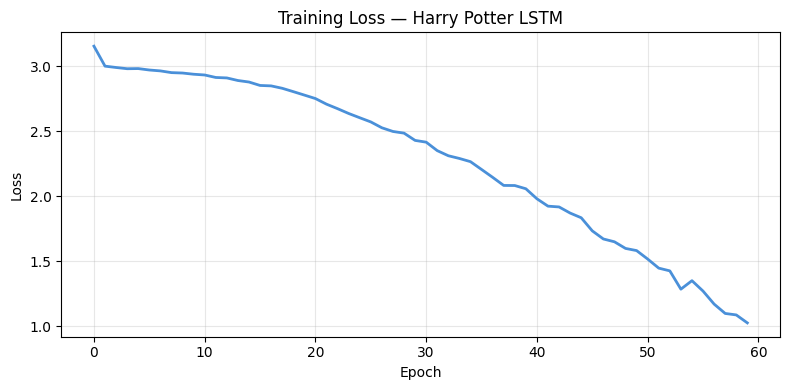

In [7]:
print("--- Training Started ---")
history = model.fit(
    X, y,
    batch_size=128,
    epochs=60,
    verbose=2
)
print("--- Training Complete ---")

# Plot loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], color='#4A90D9', linewidth=2)
plt.title('Training Loss — Harry Potter LSTM')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png")
plt.show()

In [8]:
def generate_text(seed_text, length=200, temperature=0.6):
    generated = seed_text.lower()

    # Pad if shorter than maxlen
    if len(generated) < maxlen:
        generated = (' ' * (maxlen - len(generated))) + generated

    result = seed_text

    for _ in range(length):
        # Prepare input
        x_pred = np.zeros((1, maxlen, vocab_size))
        for t, char in enumerate(generated[-maxlen:]):
            if char in char_to_idx:
                x_pred[0, t, char_to_idx[char]] = 1.0

        # Predict next character
        preds = model.predict(x_pred, verbose=0)[0]

        # Temperature sampling
        preds = np.log(preds + 1e-7) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        next_char = idx_to_char[np.random.choice(len(chars), p=preds)]
        generated += next_char
        result += next_char

    return result

# Test generation
seeds = [
    "harry potter was",
    "dumbledore said to",
    "the dark lord",
    "hermione granger",
]

print("── Harry Potter Style Text Generation ──\n")
for seed in seeds:
    print(f"Seed: '{seed}'")
    print(f"Generated: {generate_text(seed, length=150, temperature=0.6)}")
    print("-" * 60)

── Harry Potter Style Text Generation ──

Seed: 'harry potter was'
Generated: harry potter wast hoe tas sses coaden diinds pirteiss was siy cikid sss sis ciitid ss haas ciond he fffem sor ront and anterrr soter fondennin tire setere the hins sa
------------------------------------------------------------
Seed: 'dumbledore said to'
Generated: dumbledore said toeeddssslsmary wond harlyiy wart sos tin ciots sors wade the piiliss sicccozaandeedd llllrmrnnptiimenete herwan caks wao s sos liidd ciclihas shhe lalm
------------------------------------------------------------
Seed: 'the dark lord'
Generated: the dark lordpd scitee the samicconsswcapthe wanteclac asad pieniis the paruuuuss saa war hhe dhummurbrurueuaf afeeerrry an han atoius uaade gogggrwatthh qqhrrrreu
------------------------------------------------------------
Seed: 'hermione granger'
Generated: hermione grangertte the san teoninction peatteet henran s saott heowwatthe dmion tte peeete whe passs sspory wind ilillld
therreas h